# Basic Plotting

In this lesson we will learn to use the `plot()` method of a `pandas.DataFrame` to create simple exploratory graphs from tabular data.

See information about the data on [course website](https://meds-eds-220.github.io/MEDS-eds-220-course/book/chapters/lesson-3-pandas-subsetting/lesson-3-pandas-subsetting.html).

## Learning objectives
By the end of this lesson, students will be able to:

- Obtain and interpret preliminary information about a `pandas.DataFrame` using methods such as `info()` (structure), `describe()` (summary statistics), `nunique()` (unique value counts), `unique()` (distinct values), and `value_counts()` (frequency counts)
  
- Create simple exploratory plots using the `plot()` method for `pandas.DataFrames` to visualize trends and distributions

  
- Understand the concept of performing operations on a pandas.DataFrame in-place

  
- Apply method chaining to enable concise and readable code

  

## Data

We will reuse the annual estimates of bird species richness (the number of different bird species recorded) in four coastal wetlands along the California coast.

In [1]:
import pandas as pd

# Read in file
df = pd.read_csv('../data/wetlands_seasonal_bird_diversity.csv')

# Check the first 5 rows
df.head()

,year,CSM_winter,CSM_spring,CSM_fall,MUL_winter,MUL_spring,MUL_fall,SDW_winter,SDW_spring,SDW_fall,TJE_winter,TJE_spring,TJE_fall
0,2010,39.0,40.0,50.0,45.0,NaN,61.0,NaN,75.0,85.0,NaN,NaN,81.0
1,2011,48.0,44.0,NaN,58.0,52.0,NaN,78.0,74.0,NaN,67.0,70.0,NaN
2,2012,51.0,43.0,49.0,57.0,58.0,53.0,71.0,72.0,73.0,70.0,63.0,69.0
3,2013,42.0,46.0,38.0,60.0,58.0,62.0,69.0,70.0,70.0,69.0,74.0,64.0
4,2014,38.0,43.0,45.0,49.0,52.0,57.0,61.0,78.0,71.0,60.0,81.0,62.0


A `pandas.DataFrame` has a built-in method `plot()` for plotting. When we call it without specifying any other parameters `plot()` creates one line plot for each of the columns with numeric data.

<Axes: >

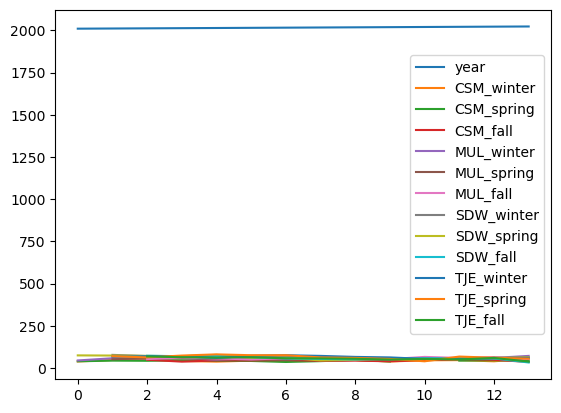

In [2]:
# Default plot(): one line plot per column with numeric data
df.plot()

## Line Plots

WE can make a line plot column against another by using:

`df.plot(x='x_values_column', y='y_values_column')`

*Example*: Plotting bird surveys at Carpinteria Salt Marsh across years

<Axes: xlabel='year'>

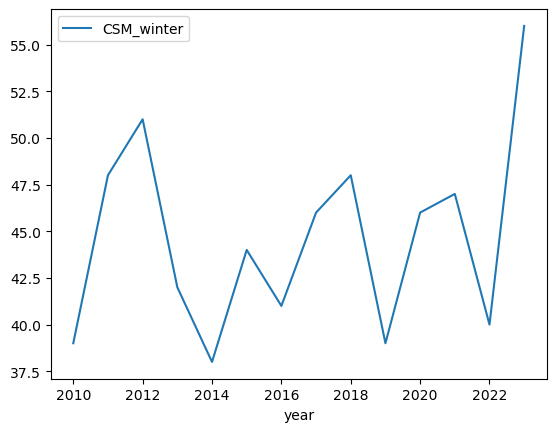

In [3]:
# Bird species registered during winter at CSM yearly
df.plot(x='year', y='CSM_winter')

We can do some basic customization specifying other parameters of the `plot()` method. Some basic ones are:

- `title`: title to use for the plot.
- `xlabel`: name to use for the x-label on x-axis
- `ylabel`: name to use for the y-label on y-axis
- `color`: change the color of our plot
- `legend`: boolean value `True` or `False`. `True` (default) includes the legend, `False` removes the legend

<Axes: title={'center': 'Bird species registered during winter at Carpinteria Salt Marsh'}, xlabel='Year', ylabel='Number of bird species'>

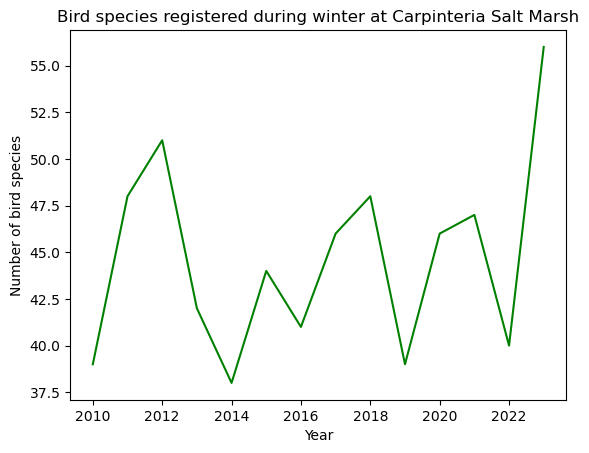

In [4]:
df.plot(x='year', 
        y='CSM_winter',
        title='Bird species registered during winter at Carpinteria Salt Marsh',
        xlabel='Year',
        ylabel='Number of bird species',
        color='green',
        legend=False
        )

## Check-In

1. Plot a graph of the spring bird surveys at Mugu Lagoon with respect to the years. Include some basic customization.

<Axes: title={'center': 'Bird species recorded at Mugu Lagoon in Spring'}, xlabel='Year', ylabel='Number of Bird Species'>

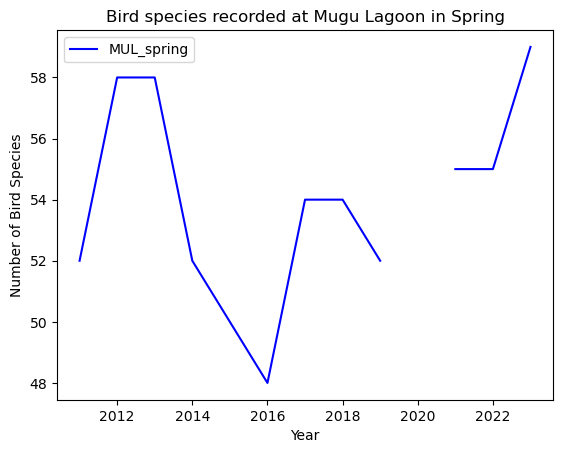

In [36]:
df.plot(x = 'year',
       y = 'MUL_spring',
       title = 'Bird species recorded at Mugu Lagoon in Spring',
        xlabel = 'Year',
        ylabel = 'Number of Bird Species',
        color = 'blue',
        legend = 'false'
       )

## Check-In 

2. Use the isna() method for pandas.Series and row selection to select the rows in which Mugu Lagoon has NAs during the spring survey.

In [6]:
df[df['MUL_spring'].isna()]

,year,CSM_winter,CSM_spring,CSM_fall,MUL_winter,MUL_spring,MUL_fall,SDW_winter,SDW_spring,SDW_fall,TJE_winter,TJE_spring,TJE_fall
0,2010,39.0,40.0,50.0,45.0,NaN,61.0,NaN,75.0,85.0,NaN,NaN,81.0
10,2020,46.0,NaN,47.0,56.0,NaN,66.0,57.0,NaN,58.0,54.0,40.0,54.0


## Multiple line plots

We can plot multiple line plots by updating these parameters in the `plot()` method:

`y` : a list of column names that will be plotted against the x-axis
`color`: a dictionary `{'column_1' : 'color_1', 'column_2':'color_2'}` specifying the color of each column’s line plot

*Example*

Let’s say we want to compare the bird surveys at the Tijuana Estuary during spring and fall across years.

<Axes: title={'center': 'Seasonal bird surveys at Tijuana Estuary'}, xlabel='Year', ylabel='Number of bird species'>

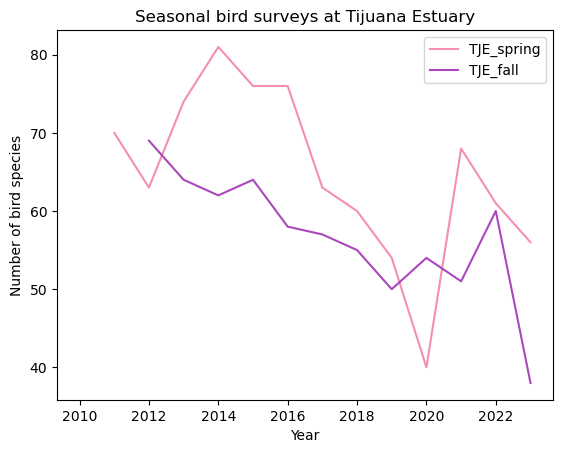

In [7]:
df.plot(x='year', 
        y=['TJE_spring', 'TJE_fall'],
        title = 'Seasonal bird surveys at Tijuana Estuary',
        xlabel='Year',
        ylabel='Number of bird species',        
        color = {'TJE_spring':'#F48FB1', # HEX code is used to give more control over color 
                 'TJE_fall': '#AB47BC'
                 }
        )

We can also create separate plots for each column by setting the `subplots` parameter to `True`.

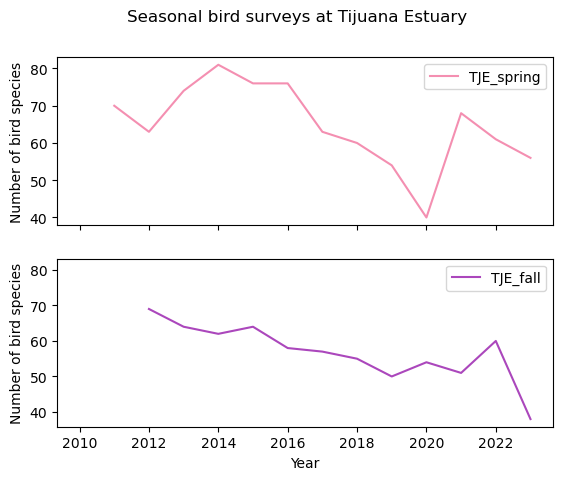

In [8]:
df.plot(x='year', 
        y=['TJE_spring', 'TJE_fall'],
        title = 'Seasonal bird surveys at Tijuana Estuary',
        xlabel='Year',
        ylabel='Number of bird species',        
        color = {'TJE_spring':'#F48FB1',
                 'TJE_fall': '#AB47BC'
                 },
        subplots=True
        ); 

# The semicolon ; at the end of the code suppresses the text output of the plot() method, 
# which is otherwise printed above the graph 
# (here, an array with the two plot objects), so that only the graph is shown.

## Updating the Index

Updating the index of our data frame to be something other than the default integers numbering the rows can be a useful operation for plotting. To update the index we use the `set_index()` method for a `pandas.DataFrame`. 

Its general syntax is:

`df = df.set_index(new_index)`

where `new_index` is:

- the name of the column in the data frame `df` we want to use as new index
- if our new index is not a column in the data frame, an array or `pandas.Series` of the same length as our data frame (we need one index per row).
This operation does not happen in-place.

- A function **acting in-place** means that our original object (in this case a `pandas.DataFrame`) is modified.
- If the function **does not act in-place**, a new object (in this case a `pandas.DataFrame`) is created and the original is not modified.

If we wanted to update our df data frame we could do an **explicit assignment** to reassign the output of `set_index()` to df:

Set `column_name` column in df as the new index (reassignment)

`df = df.set_index('column_name')`

or use the optional inplace parameter:

Set `column_name` column in df as the new index (modify df in-place)

`df.set_index('column_name', inplace=True)`

*Example*
In all our previous examples we used the year column as the x-axis. Since all our bird survey variables are dependent on the year, it makes sense to use the year column as the index of the data frame:

In [9]:
# Update index to be the year column
df = df.set_index('year')
df.head()

,CSM_winter,CSM_spring,CSM_fall,MUL_winter,MUL_spring,MUL_fall,SDW_winter,SDW_spring,SDW_fall,TJE_winter,TJE_spring,TJE_fall
year,,,,,,,,,,,,
2010,39.0,40.0,50.0,45.0,NaN,61.0,NaN,75.0,85.0,NaN,NaN,81.0
2011,48.0,44.0,NaN,58.0,52.0,NaN,78.0,74.0,NaN,67.0,70.0,NaN
2012,51.0,43.0,49.0,57.0,58.0,53.0,71.0,72.0,73.0,70.0,63.0,69.0
2013,42.0,46.0,38.0,60.0,58.0,62.0,69.0,70.0,70.0,69.0,74.0,64.0
2014,38.0,43.0,45.0,49.0,52.0,57.0,61.0,78.0,71.0,60.0,81.0,62.0


<Axes: xlabel='year'>

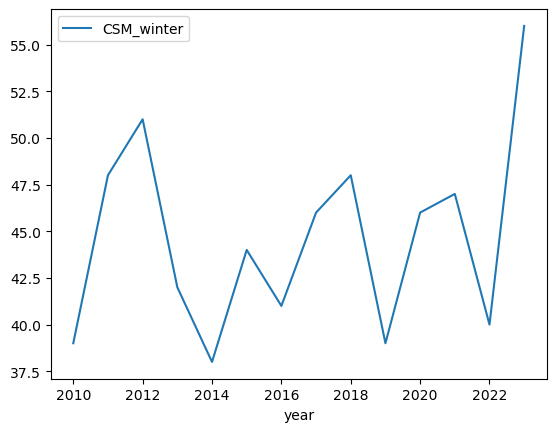

In [10]:
# Simple plot of Carpinteria Salt Marsh winter surveys
df.plot(y='CSM_winter')

In [11]:
# If needed, we can reset the index to be the numbering of the rows

df = df.reset_index()
df.head()

,year,CSM_winter,CSM_spring,CSM_fall,MUL_winter,MUL_spring,MUL_fall,SDW_winter,SDW_spring,SDW_fall,TJE_winter,TJE_spring,TJE_fall
0,2010,39.0,40.0,50.0,45.0,NaN,61.0,NaN,75.0,85.0,NaN,NaN,81.0
1,2011,48.0,44.0,NaN,58.0,52.0,NaN,78.0,74.0,NaN,67.0,70.0,NaN
2,2012,51.0,43.0,49.0,57.0,58.0,53.0,71.0,72.0,73.0,70.0,63.0,69.0
3,2013,42.0,46.0,38.0,60.0,58.0,62.0,69.0,70.0,70.0,69.0,74.0,64.0
4,2014,38.0,43.0,45.0,49.0,52.0,57.0,61.0,78.0,71.0,60.0,81.0,62.0


## Check-In 

1. Without running the code, give a step-by-step breakdown of what this code is doing:
   
   `df.set_index('year').loc[:,'SDW_winter':'TJE_fall'].plot()`

    Sets the index of the data frame to the year. 
    Selecting all rows and the columns from `SDW_winter` to `TJE_fall` and plotting

2. Is this code modifying the data frame df? Why or why not?

   It is not modifying the dataframe because it was not assigning the function to a dataframe
   It would have modified it if it had been df = df .set...

4. Run the code and examine the graph. Review the data description. Do we have all the necessary information to make sure it makes sense to directly compare the surveys at these different sites?

<Axes: xlabel='year'>

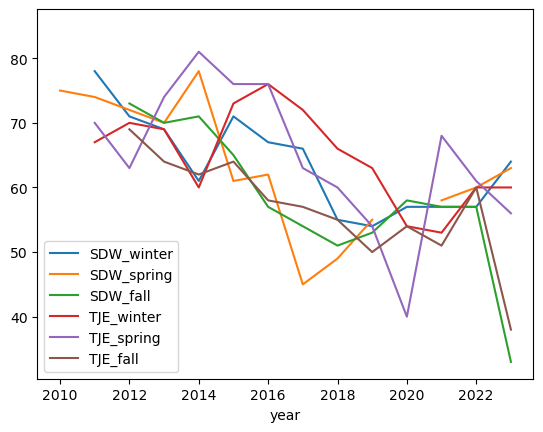

In [12]:
df.set_index('year').loc[:,'SDW_winter':'TJE_fall'].plot()

## Method chaining##

The code used in the check-in

`df.set_index('year').loc[:,'SDW_winter':'TJE_fall'].plot()`

is an example of method chaining. Each method in the chain returns a new object (usually a pandas.DataFrame or pandas.Series), allowing the next method to be called directly on the result. This is a powerful technique that makes code concise and readable.

Chaining methods can result in lines of code that are too long and hard to read. 

We can break up chains of methods by using parentheses:

<Axes: xlabel='year'>

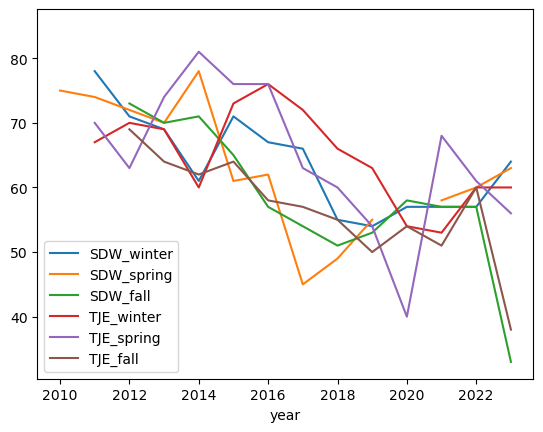

In [13]:
(df.set_index('year')
  .loc[:,'SDW_winter':'TJE_fall']
  .plot()
)

<Axes: xlabel='year'>

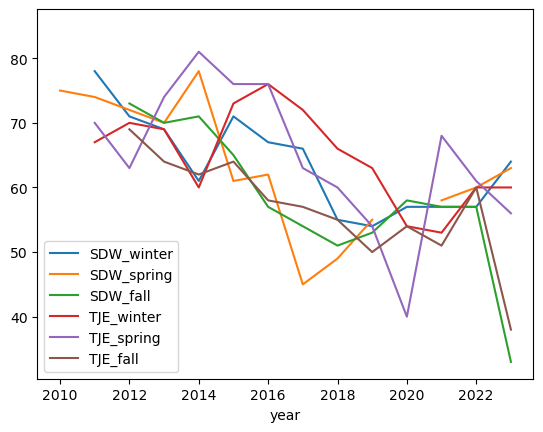

In [14]:
# An alternative to the previous code chaining could have been:

year_index_df = df.set_index('year')
subset_df = year_index_df.loc[:,'SDW_winter':'TJE_fall']
subset_df.plot()

# While this accomplishes the same output
# Several variables are created along the way and it can be difficult to keep track of what is what.

## Data

For the next plots we will use the Palmer Penguins dataset [2] developed by Drs. Allison Horst, Alison Hill and Kristen Gorman. This dataset contains size measurements for three penguin species in the Palmer Archipelago, Antarctica, during 2007, 2008, and 2009.

In [15]:
# Read in data
URL = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
penguins = pd.read_csv(URL)

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [16]:
# Check column data types and NA values
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB


In [17]:
# Simple statistics about numeric columns
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


In [18]:
# Count unique values in categorical columns and year
penguins[['species', 'island', 'sex', 'year']].nunique()

species    3
island     3
sex        2
year       3
dtype: int64

In [19]:
# Get unique values in species column
penguins['species'].unique()

array(['Adelie', 'Gentoo', 'Chinstrap'], dtype=object)

In [20]:
# Number of values per unique value in species column
penguins['species'].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

## `kind` argument in `plot()`

At the beginning of the lesson we talked about how the `plot()` method creates a line plot by default. The parameter that controls this behaviour is the `kind` parameter. By changing the value of `kind` we can create different kinds of plots. The default value of `kind` is `line`.

## Scatter plots

Suppose we want to visually compare the flipper length against the body mass.
We can do this with a scatter plot:

<Axes: xlabel='flipper_length_mm', ylabel='body_mass_g'>

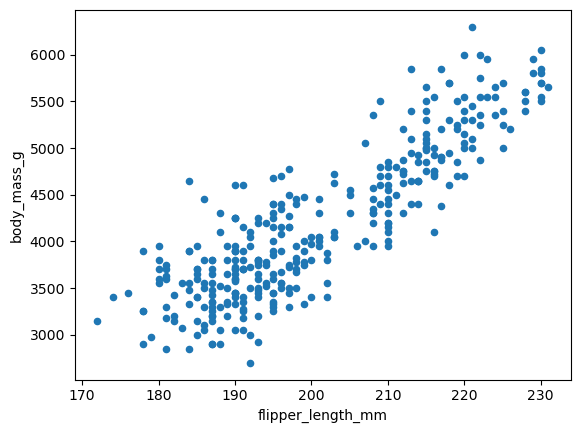

In [21]:
penguins.plot(kind='scatter',
              x='flipper_length_mm', 
              y='body_mass_g')

We can update some other arguments to customize the graph:

<Axes: title={'center': 'Flipper length and body mass for Palmer penguins'}, xlabel='Flipper length (mm)', ylabel='Body mass (g)'>

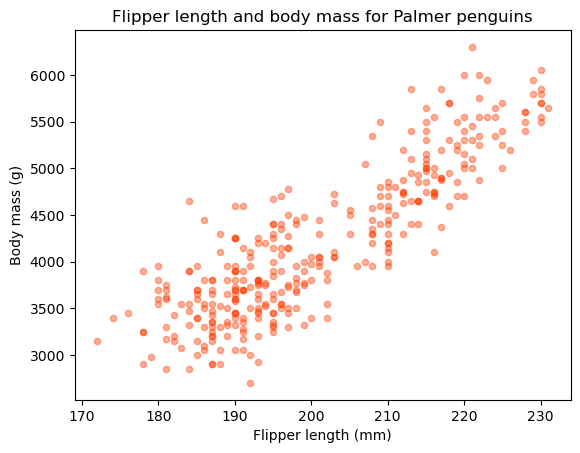

In [22]:
penguins.plot(kind='scatter',
              x='flipper_length_mm', 
              y='body_mass_g',
              title='Flipper length and body mass for Palmer penguins',
              xlabel='Flipper length (mm)',
              ylabel='Body mass (g)',
              color='#ff3b01',
              alpha=0.4  # Controls transparency
              )

## Bar plots

We can create bar plots of our data by setting `kind=bar` in the `plot()` method.

*Example* 

Let’s say we want to get data about the 10 penguins with the lowest body mass. We can first select this data using the `nsmallest()` method for series:

In [23]:
smallest = penguins['body_mass_g'].nsmallest(10)
smallest

314    2700.0
58     2850.0
64     2850.0
54     2900.0
98     2900.0
116    2900.0
298    2900.0
104    2925.0
47     2975.0
44     3000.0
Name: body_mass_g, dtype: float64

<Axes: >

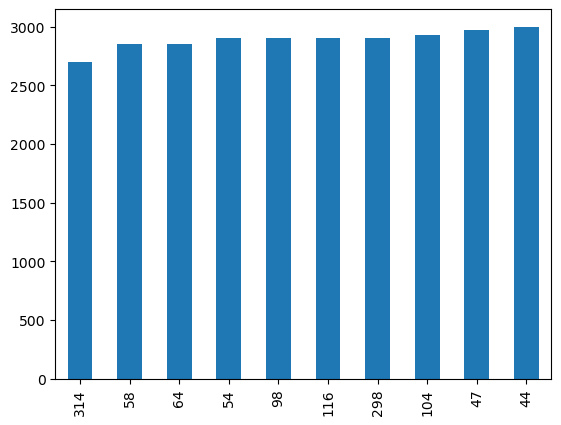

In [24]:
smallest.plot(kind='bar')

In [25]:
penguins.nsmallest(10, 'body_mass_g')

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
314,Chinstrap,Dream,46.9,16.6,192.0,2700.0,female,2008
58,Adelie,Biscoe,36.5,16.6,181.0,2850.0,female,2008
64,Adelie,Biscoe,36.4,17.1,184.0,2850.0,female,2008
54,Adelie,Biscoe,34.5,18.1,187.0,2900.0,female,2008
98,Adelie,Dream,33.1,16.1,178.0,2900.0,female,2008
116,Adelie,Torgersen,38.6,17.0,188.0,2900.0,female,2009
298,Chinstrap,Dream,43.2,16.6,187.0,2900.0,female,2007
104,Adelie,Biscoe,37.9,18.6,193.0,2925.0,female,2009
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN,2007
44,Adelie,Dream,37.0,16.9,185.0,3000.0,female,2007


## Histograms

We can create a histogram of our data by setting `kind = 'hist` in `plot()`.

<Axes: ylabel='Frequency'>

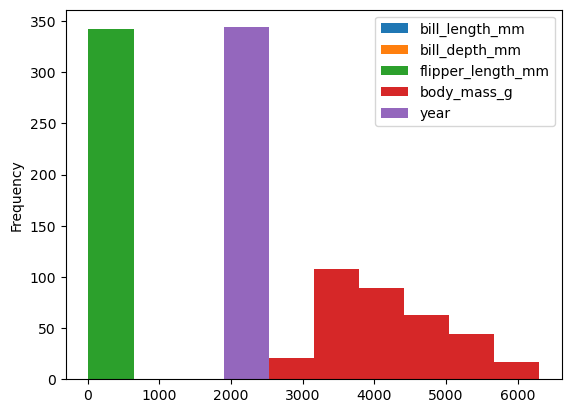

In [26]:
# Using plot without subsetting data - a mess again
penguins.plot(kind='hist')

To gain actual information, let’s subset the data before plotting it. 

*Example*

Suppose we want to do a preliminary graph for the distribution of flipper length. We could do it in this way:

<Axes: title={'center': 'Penguin flipper lengths'}, xlabel='Flipper length (mm)', ylabel='Frequency'>

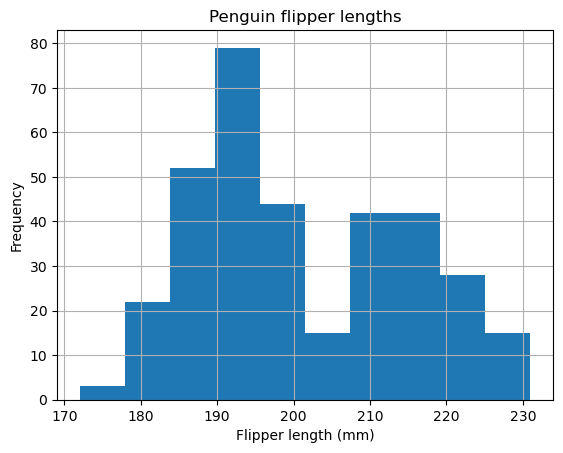

In [27]:
# Distribution of flipper length measurements
# First select data, then plot
penguins['flipper_length_mm'].plot(kind='hist',
                                title='Penguin flipper lengths',
                                xlabel='Flipper length (mm)',
                                grid=True)

## Check-in

1. Select the `bill_length_mm` and `bill_depth_mm` columns in the `penguins` data frame and then update the `kind` parameter to `box` to make boxplots of the bill length and bill depth.

<Axes: title={'center': 'Penguin Bill Length and Bill Depth'}, ylabel='Frequency'>

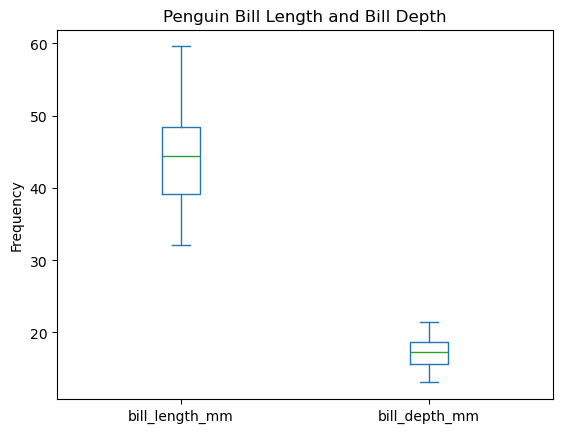

In [28]:
penguins[['bill_length_mm', 'bill_depth_mm']].plot(kind = 'box',
                                                   ylabel = 'Frequency'
                                                 ,title = 'Penguin Bill Length and Bill Depth')

## Check-In

2. Create a simple histogram of the flipper length of female gentoo penguins.

<Axes: title={'center': 'Female Gentoo Penguin Flipper Length'}, xlabel='Flipper Length (mm)', ylabel='Frequency'>

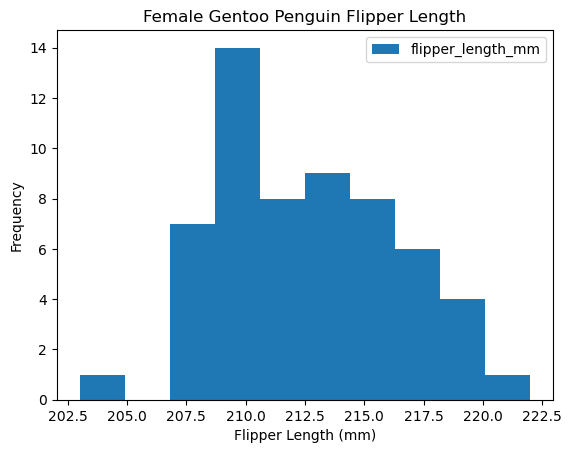

In [35]:
penguins[(penguins['sex'] == 'female') & (penguins['species'] == 'Gentoo')][['flipper_length_mm']].plot(kind = 'hist', 
                                                                                                       title = 'Female Gentoo Penguin Flipper Length',
                                                                                                       xlabel = 'Flipper Length (mm)',
                                                                                                       legend = 'Blank')